In [1]:
!pip install pulser

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.8/267.8 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 44.0 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.6/122.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.0/472.0 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 50.9 MB/s eta 0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 34.5 MB/s eta 0:00:00
  Attempting uninstall: jsonschema
    Found existing installation: jsonschema 4.10.3
    Not uninstalling jsonschema at /usr/lib/python3/dist-packages, outside environmen

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import isclose
from pulser import Pulse, Sequence, Register
from pulser_simulation import QutipEmulator
from pulser.waveforms import InterpolatedWaveform
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
from pulser.devices import DigitalAnalogDevice


# Quadratic Unconstrained Binary Optimization problems

Today we want to solve an optimization problem with a neutral-atom quantum computer. First we need to introduce a class of problems very famous in quantum computing (both digital and analog): the Quadratic Unconstrained Binary Optimization (QUBO) Problems.

Mathematically, a QUBO instance consists of a symmetric matrix $Q$ of size $(N \times N)$, and the optimization problem associated with it is to find the bitstring $z=(z_1, \dots, z_N) \in \{0, 1 \}^N$ that minimizes the quantity

$$f(z) = z^{T}Qz$$

### Exercise 1
Formulate as a QUBO problem the following problem: minimize
$$
y = -5x_1-3x_2-8x_3-6x_4+4x_1x_2+8x_1x_3+2x_2x_3+10x_3x_4
$$
where the variables, $x_j$, are binary variables.
Hint: Try to write it as
$$
y = x^T Q x =
\begin{pmatrix}
x1 & x2 & x3 & x4
\end{pmatrix}
Q
\begin{pmatrix}
x1 \\ x2 \\ x3 \\ x4
\end{pmatrix}
$$

#### Solution 1
...

In [ ]:
# code here

## Atomic (Quantum) Register

In neutral atoms devices the array/layout of the atoms in physical space is called `Register`. Commonly to all SDKs, in order to place an atom at a certain position you need to declare its position vector (in 2D or 3D depending on the device) relative to the center of the QPU. We will only consider the 2-dimensional case.

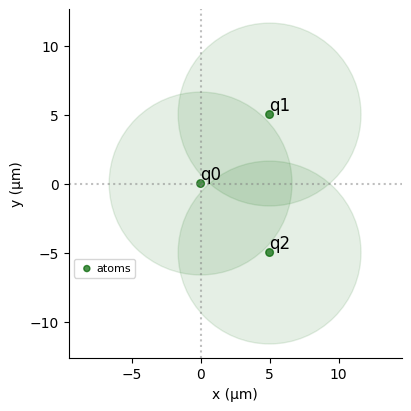

In [4]:
coords = np.array([[0, 0], [5, 5], [5, -5]])

qubits = {f"q{i}": coord for (i, coord) in enumerate(coords)}
reg = Register(qubits)
reg.draw(
    blockade_radius=DigitalAnalogDevice.rydberg_blockade_radius(rabi_frequency=1.0),
    draw_graph=False,
    draw_half_radius=True,
)

### Exercise 2
Build the registers associated with the following graphs:

- open line
- closed line (circle/polygon)
- square grid

#### Solution 2

In [1]:
# code here

### Embedding QUBO problems onto an atomic register

Consider the following QUBO matrix $Q$:

In [6]:
Q = np.array(
    [
        [-10.0, 19.7365809, 19.7365809, 5.42015853, 5.42015853],
        [19.7365809, -10.0, 20.67626392, 0.17675796, 0.85604541],
        [19.7365809, 20.67626392, -10.0, 0.85604541, 0.17675796],
        [5.42015853, 0.17675796, 0.85604541, -10.0, 0.32306662],
        [5.42015853, 0.85604541, 0.17675796, 0.32306662, -10.0],
    ]
)

This QUBO instance is particularly amenable to embedding on a neutral-atom device since:

1. All the off-diagonal terms are positive.
2. The diagonal terms are all equal.

Furthermore, because the QUBO is small, we can classically check all solutions and mark the optimal ones. This will help us later in the tutorial to visualize the quality of our quantum approach.

In [ ]:
bitstrings = [np.binary_repr(i, len(Q)) for i in range(2 ** len(Q))]
costs = []

# this takes exponential time with the dimension of the QUBO
for b in bitstrings:
    z = np.array(list(b), dtype=int)
    cost = z.T @ Q @ z
    costs.append(cost)
zipped = zip(bitstrings, costs)
sort_zipped = sorted(zipped, key=lambda x: x[1])

# save expected solutions
solution_cost = sort_zipped[0][1]
solutions = []
for sols in sort_zipped:
  if isclose(sols[1], solution_cost, abs_tol=1e-6):
    solutions.append(sols[0])


print(solutions)

['01011', '00111']


This QUBO admits `01011` and `00111` as optimal solutions.

We now illustrate how to use Pulser to embbed the QUBO matrix $Q$ on a neutral-atom device.

The key idea is to encode the off-diagonal terms of $Q$ by using the Rydberg interaction between atoms. Recalling that the interaction between two atoms is given by

$$
U_{ij}=C_6/r_{ij}^6,
$$

we note that

1. The term is strictly positive, which is why it matters that our off-diagonal terms are too.
2. Its magnitude depends on the pairwise distance between atoms $i$ and $j$, $r_{ij}$.


| Q matrix element | Physical parameter | Control mechanism |
| --- | --- | --- |
| $Q_{ii}= Q_{jj}$ | Detuning | Global field |
| $Q_{ii}\neq Q_{jj}$ | Detuning | Local field |
| $Q_{ij}\ge 0$ | Rydberg interaction strength | Distance between atoms in register |
| $Q_{ij}< 0$ | Advanced techniques | - |

As such, we attempt a simple minimization procedure to find the optimal positions of the atoms in the Register that replicate best the off-diagonal terms of $Q$:

In [8]:
def evaluate_mapping(new_coords, Q):
    """Cost function to minimize. Ideally, the pairwise distances are conserved."""
    new_coords = np.reshape(new_coords, (len(Q), 2))
    # computing the matrix of the distances between all coordinate pairs
    new_Q = squareform(
        DigitalAnalogDevice.interaction_coeff / pdist(new_coords) ** 6
    )
    return np.linalg.norm(new_Q - Q)

If you are wondering what `squareform`:
Given a $n\cdot (n-1) /2 $ sized vector $v$ for some integer $n\ge 1$ encoding distances, the function returns a $n\times n$ distance matrix $X$. The `X[i,j]` and `X[j, i]` values are set to

$$
X[i,j] = v\left[{n \choose 2} - {n-1 \choose 2} + (j-i-1)\right]
$$

and all diagonal elements are set to zero.

In [9]:
costs = []
np.random.seed(0)
x0 = np.random.random(len(Q) * 2)
res = minimize(
    evaluate_mapping,
    x0,
    args=(Q,),
    method="Nelder-Mead",
    tol=1e-6,
    options={"maxiter": 200000, "maxfev": None},
)

# reshape the solution vector x as a list of len(Q) pairs
coords = np.reshape(res.x, (len(Q), 2))

>&#9888;&#65039; **Attention:** Atoms MUST be positioned within $50\mu$m from the center of the trap!

>&#9888;&#65039; **Attention:** Minimal distance between atoms is $4\mu$m!

Let's plot the obtained coordinates of atoms:

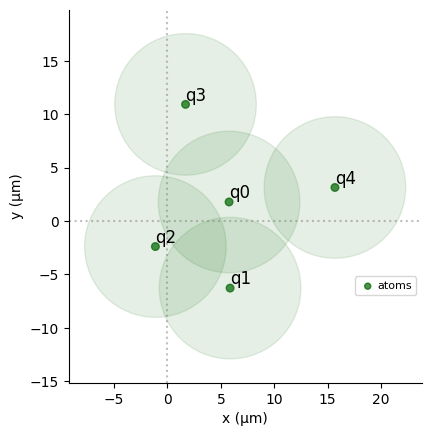

In [10]:
qubits = {f"q{i}": coord for (i, coord) in enumerate(coords)}
reg = Register(qubits)
reg.draw(
    blockade_radius=DigitalAnalogDevice.rydberg_blockade_radius(rabi_frequency=1.0),
    draw_graph=False,
    draw_half_radius=True,
)

>&#9888;&#65039; **Attention:** This simple procedure was enough to give a good and valid embedding but it will not always be so. For QUBO instances that are not as easy to embbed as this one, more complex embedding strategies are required.

---

Now that the QUBO $Q$ is encoded in the Register, we can peprare the following Ising Hamiltonian $H_Q$:

$$ H_Q= \sum_{i=1}^N \frac{\Omega}{2} \sigma_i^x - \sum_{i=1}^N \frac{\delta}{2} \sigma_i^z+\sum_{j \lt i}\frac{C_6}{|\textbf{r}_i-\textbf{r}_j|^{6}} n_i n_j. $$

In the case where our mapping of the atoms is perfect, the last sum replicates exactly the off-diagonal terms of $Q$. Additionally, since the diagonal terms are all the same, we can use a Rydberg global beam with an approriate detuning $\delta$ (otherwise, some kind of local addressability capabilities would be necessary).

As such, the next step is to prepare the ground-state of $H_Q$ to output the optimal bitstrings. To do so we present two different approaches, namely the Quantum Approximation Optimization Algorithm (QAOA) and the Quantum Adiabatic Algorithm (QAA) that have been introduced to prepare ground-states of Hamiltonians.

## Quantum Approximate Optimization Algorithm (QAOA)

This algorithm (see [Farhi, et al., 2014](https://arxiv.org/pdf/1411.4028.pdf)) has gained a lot of interest lately as a gate-based quantum algorithm. It has shown promising results in a number of applications and yields decent results for low-depth circuits.

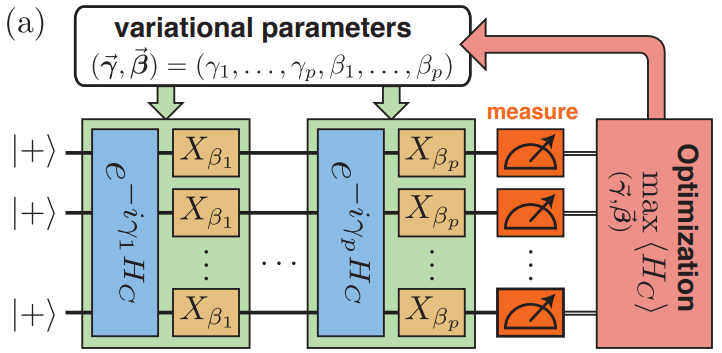



All atoms are initially in the groundstate $|00\dots0\rangle$ of the `ground-rydberg` basis.  We then apply $p$ layers of alternating non-commutative Hamiltonians. The first one, called the mixing Hamiltonian $H_M$, is realized by taking $\Omega = 1$ rad/µs, and $\delta = 0$ rad/µs in the Hamiltonian equation. The second Hamiltonian $H_Q$ is realized with $\Omega =0$ rad/µs and $\delta = 1.$ rad/µs. $H_M$ and $H_Q$ are applied turn in turn with parameters $\tau$ and $t$ respectively. A classical optimizer is then used to estimate the optimal parameters.

Instead of creating a new `Sequence` everytime the quantum loop is called, we are going to create a parametrized `Sequence` and give that to the quantum loop.

In [11]:
from pulser.devices import DigitalAnalogDevice, AnalogDevice, MockDevice


# Parametrized sequence
seq = Sequence(reg, MockDevice)
for channel, props in seq.available_channels.items():
  print(channel)
  print("\t", props, "\n")

rydberg_global
	 Rydberg.Global(Max Absolute Detuning: None, Max Amplitude: None, Clock period: 1 ns, Minimum pulse duration: 1 ns, Supports EOM: False, Basis: 'ground-rydberg') 

rydberg_local
	 Rydberg.Local(Max Absolute Detuning: None, Max Amplitude: None, Minimum retarget time: 0 ns, Fixed retarget time: 0 ns, Clock period: 1 ns, Minimum pulse duration: 1 ns, Supports EOM: False, Basis: 'ground-rydberg') 

raman_global
	 Raman.Global(Max Absolute Detuning: None, Max Amplitude: None, Clock period: 1 ns, Minimum pulse duration: 1 ns, Supports EOM: False, Basis: 'digital') 

raman_local
	 Raman.Local(Max Absolute Detuning: None, Max Amplitude: None, Minimum retarget time: 0 ns, Fixed retarget time: 0 ns, Clock period: 1 ns, Minimum pulse duration: 1 ns, Supports EOM: False, Basis: 'digital') 

mw_global
	 Microwave.Global(Max Absolute Detuning: None, Max Amplitude: None, Clock period: 1 ns, Minimum pulse duration: 1 ns, Supports EOM: False, Basis: 'XY') 

dmm_0
	 DMM.Global(Max Absolu

In [12]:
LAYERS = 2

seq.declare_channel("ch0", "rydberg_global")

t_list = seq.declare_variable("t_list", size=LAYERS)
s_list = seq.declare_variable("s_list", size=LAYERS)

for t, s in zip(t_list, s_list):
    pulse_1 = Pulse.ConstantPulse(
        duration = 1000 * t,  # microseconds to nanoseconds
        amplitude = 1.0,
        detuning = 0.0,
        phase = 0)
    pulse_2 = Pulse.ConstantPulse(
        duration = 1000 * s,  # microseconds to nanoseconds
        amplitude = 0.0,
        detuning = 1.0,
        phase = 0)

    seq.add(pulse_1, "ch0")
    seq.add(pulse_2, "ch0")

seq.measure("ground-rydberg")

Once we have the parameters that we want to apply, we use the `.build()` method to assign these values into a `assigned_seq` sequence. It is this sequence which is simulated every time the quantum loop is called.

Experimentally, we don't have access to the state vector $|\psi\rangle$. We therefore make it more realistic by taking samples from the state vector that results from running the simulation with `simul.run()`. This is done with the built-in method `results.sample_final_state()`, in which we add the measurement basis which was declared at the end of the sequence, and the number of samples desired. Currently, the repetition rate of the machine is $5$ Hz.

In [13]:
def quantum_loop(parameters):
    # params = [tt...taa...a]
    params = np.array(parameters)
    # reshape into
    # ( [tt...t],
    #   [aa...a] )
    t_params, s_params = np.reshape(params.astype(int), (2, LAYERS))
    assigned_seq = seq.build(t_list=t_params, s_list=s_params)
    simul = QutipEmulator.from_sequence(assigned_seq, sampling_rate=0.05)
    results = simul.run()
    count_dict = results.sample_final_state()  # sample from the state vector
    return count_dict

In [14]:
np.random.seed(123)  # ensures reproducibility of the tutorial
guess = {
    "t": np.random.uniform(8, 10, LAYERS),
    "s": np.random.uniform(1, 3, LAYERS),
}

In [15]:
# np.r_ translates slice objects to concatenation along the first axis
example_dict = quantum_loop(np.r_[guess["t"], guess["s"]])

We can then plot the distribution of the samples, to see the most frequent bitstrings sampled.

In [16]:
def plot_distribution(C):
    C = dict(sorted(C.items(), key=lambda item: item[1], reverse=True))
    indexes = solutions # QUBO solutions
    color_dict = {key: "r" if key in indexes else "g" for key in C}
    plt.figure(figsize=(8, 2))
    plt.xlabel("bitstrings")
    plt.ylabel("counts")
    plt.bar(C.keys(), C.values(), width=0.5, color=color_dict.values())
    plt.xticks(rotation="vertical")

    colors = {'suboptimal': 'green', 'optimal': 'red'}
    labels = list(colors.keys())
    handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]
    plt.legend(handles, labels, frameon=False)

    plt.show()

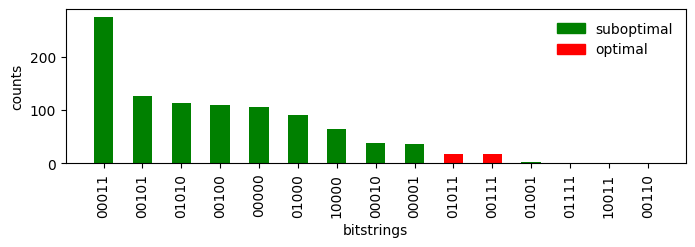

In [17]:
plot_distribution(example_dict)

The bitstrings `01011` and `00111` (in red) correspond to the two optimal solutions (calculated at the beginning of the notebook). The goal of QAOA is to choregraph interferences between the basis states, in order to maximize the frequency of the optimal solution states.

Now we solve the optimization problem with the quantum computer. But first we need to estimate the cost of a sampled state vector by making an average over the samples. This is done by taking the corresponding bitstring ${\bf z}=(z_1, \ldots, z_N)$ and calculating

$$
C({\bf z}) = {\bf z}^\top \cdot Q \cdot {\bf z}
$$

Determining the cost of a given bitstring takes polynomial time. The average estimate is then used in the classical loop to optimize the variational parameters $\tau$ and $t$.

In [18]:
def get_cost_colouring(bitstring, Q):
    z = np.array(list(bitstring), dtype=int)
    cost = z.T @ Q @ z
    return cost


def get_cost(counter, Q):
    cost = sum(counter[key] * get_cost_colouring(key, Q) for key in counter)
    return cost / sum(counter.values())  # Divide by total samples

To perform a minimization loop, we define the following function that will be called at each step by SciPy. `*args` enables to pass the QUBO value, and `params` contains the trial value to score, which changes at each step.

In [19]:
def func(param, *args):
    Q = args[0]
    C = quantum_loop(param)
    cost = get_cost(C, Q)
    return cost

We now use a classical optimizer `minimize` in order to find the best variational parameters. This function takes as arguments `func`, the QUBO $Q$ and an initial point `x0` for the simplex in Nelder-Mead minimization. As the optimizer might get trapped in local minima, we repeat the optimization 20 times and select the parameters that yield the best approximation ratio.

In [ ]:
scores = []
params = []
for repetition in range(20):
    guess = {
        "t": np.random.uniform(5, 10, LAYERS),
        "s": np.random.uniform(1, 5, LAYERS),
    }

    try:
        res = minimize(
            func,
            args=Q,
            x0=np.r_[guess["t"], guess["s"]],
            method="Nelder-Mead",
            tol=1e-5,
            options={"maxiter": 10},
        )
        scores.append(res.fun)
        params.append(res.x)
    except Exception as e:
        pass

We can now plot the sample that we woud obtain using the optimal variational parameters.

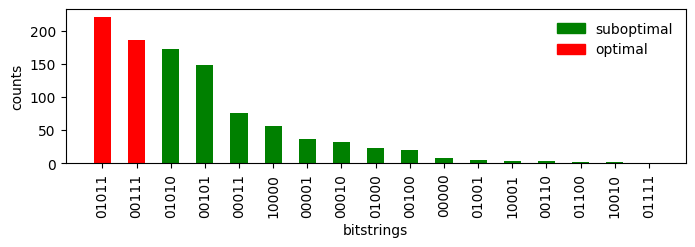

In [ ]:
optimal_count_dict = quantum_loop(params[np.argmin(scores)])
plot_distribution(optimal_count_dict)

QAOA is capable of finding good variational parameters $t$ and $s$. Now, sampling from this final state $|\psi(t_{f})\rangle$ will return both optimal strings with high probability.

### Exercise 3
Several important problems fall naturally into the QUBO class. Here an example.

**Number Partitioning Problem**

A common version of this problem involves partitioning a set of numbers into two subsets such that the subset sums are as close to each other as possible. We model this problem as a QUBO instance as follows:

Consider a set of numbers $\mathcal{S} = \{s_1, \dots, s_m\}$. Let $x_j=1$ if $\mathcal{S}_j$ is assigned to subset 1 and $x_j=0$ otherwise. Then the sum for subset 1 is given by $\Sigma_1 = \sum_j s_j x_j$ and the sum for subset 2 is given by $\Sigma_2 = \sum_j s_j - \sum_j s_j x_j$. The difference in the sums is then

$$
\Delta = \Sigma_2 - \Sigma_1 = \sum_j s_j - 2\sum_j s_j x_j = c - 2\sum_j s_j x_j
$$

We approach the goal of minimizing this difference by minimizing
$$
\Delta^2 = c^2 + 4z^TQz
$$
where
$$
Q_{ii} = s_i(s_i-c)\qquad Q_{ij}=s_is_j
$$

Dropping the additive and multiplicative constants, our QUBO optimization becomes: minimize $y=z^TQz$.

Consider the following set of numbers: $\mathcal{S}=\{3, 1, 1, 2, 2, 1\}$. Use the QAOA algorithm on neutral atom quantum computer in order to find the solution of the problem. (Expected solution, not unique, $\Sigma=5$, e.g. $\{3, 1, 1\}$ and $\{2, 2, 1\}$).


#### Solution 3

In [1]:
# print the Q matrix

The rest is as shown in the cells before. Note that for the QAOA you can try adding more layers to solve this problem (5 works even if it is slow).
The proper way should involve tuning the rabi frequency, since this time the diagonal elements are not all the same.

In [3]:
# code here QAOA

However, using QAOA to solve the problem is not the best idea; it's difficult to yield a >90% quality solution without going to high depths of the QAOA, implying that the growing closed-loop optimization can rapidly become expensive, with no guarantee of convergence. We therefore propose another approach called the Quantum Adiabatic Algorithm (QAA). This fast, reliant and exclusively analog method shows optimal convergence to the solution.

## Quantum Adiabatic Algorithm (QAA)

The idea behind the adiabatic algorithm (see [Albash, Lidar, 2018](https://arxiv.org/pdf/1611.04471.pdf)) is to slowly evolve the system from an easy-to-prepare groundstate to the groundstate of $H_Q$. If done slowly enough, the system of atoms stays in the instantaneous ground-state.

In our case, we continuously vary the parameters $\Omega(t), \delta(t)$ in time, starting with $\Omega(0)=0, \delta(0)<0$ and ending with $\Omega(0)=0, \delta>0$. The ground-state of $H(0)$ corresponds to the initial state $|00000\rangle$ and the ground-state of $H(t_f)$ corresponds to the ground-state of $H_Q$.

To ensure that we are not exciting the system to states that are too excited, we keep $\Omega \in [0, \Omega_{\text{max}}]$, and choose $\Omega_{\text{max}}$ as the median of the values of Q to ensures that the adiabatic path is efficient.

In [ ]:
Q = np.array(
    [
        [-10.0, 19.7365809, 19.7365809, 5.42015853, 5.42015853],
        [19.7365809, -10.0, 20.67626392, 0.17675796, 0.85604541],
        [19.7365809, 20.67626392, -10.0, 0.85604541, 0.17675796],
        [5.42015853, 0.17675796, 0.85604541, -10.0, 0.32306662],
        [5.42015853, 0.85604541, 0.17675796, 0.32306662, -10.0],
    ]
)

costs = []
np.random.seed(0)
x0 = np.random.random(len(Q) * 2)
res = minimize(
    evaluate_mapping,
    x0,
    args=(Q,),
    method="Nelder-Mead",
    tol=1e-6,
    options={"maxiter": 200000, "maxfev": None},
)

# reshape the solution vector x as a list of len(Q) pairs
coords = np.reshape(res.x, (len(Q), 2))

In [ ]:
# We choose a median value between the min and the max
Omega = np.median(Q[Q > 0].flatten())
delta_0 = -5  # just has to be negative
delta_f = -delta_0  # just has to be positive
T = 1000  # time in ns, we choose a time long enough to ensure the propagation of information in the system

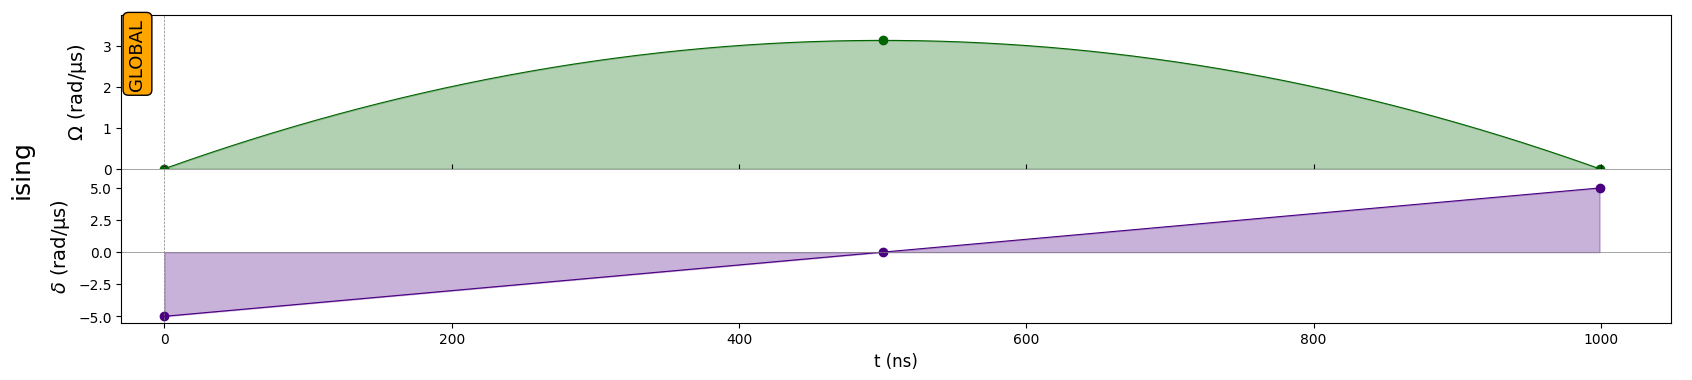

In [ ]:
adiabatic_pulse = Pulse(
    InterpolatedWaveform(T, [1e-9, Omega, 1e-9]),
    InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0,
)
seq = Sequence(reg, DigitalAnalogDevice)
seq.declare_channel("ising", "rydberg_global")
seq.add(adiabatic_pulse, "ising")
seq.draw()

In [ ]:
simul = QutipEmulator.from_sequence(seq)
results = simul.run()
final = results.get_final_state()
count_dict = results.sample_final_state()

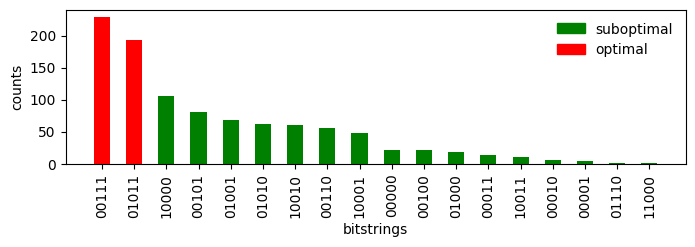

In [ ]:
plot_distribution(count_dict)

See how fast and performant this method is! In only a few micro-seconds, we find an excellent solution.

In [ ]:
cost = []
for T in 1000 * np.linspace(1, 10, 10):
    seq = Sequence(reg, DigitalAnalogDevice)
    seq.declare_channel("ising", "rydberg_global")
    adiabatic_pulse = Pulse(
        InterpolatedWaveform(T, [1e-9, Omega, 1e-9]),
        InterpolatedWaveform(T, [delta_0, 0, delta_f]),
        0,
    )
    seq.add(adiabatic_pulse, "ising")
    simul = QutipEmulator.from_sequence(seq)
    results = simul.run()
    final = results.get_final_state()
    count_dict = results.sample_final_state()
    cost.append(get_cost(count_dict, Q))

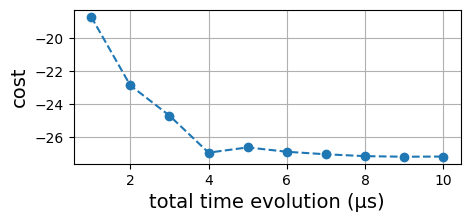

In [ ]:
plt.figure(figsize=(5, 2))
plt.plot(range(1, 11), np.array(cost), "--o")
plt.xlabel("total time evolution (µs)", fontsize=14)
plt.ylabel("cost", fontsize=14)
plt.grid()
plt.show()

### Exercise 4

Solve the partitioning problem with the QAA algorithm.

#### Solution 4

In [ ]:
# copy-paste the Q matrix

In [ ]:
# code here the QAA

### Exercise 5
Solve the following number partitioning problem both with QAOA and QAA

$\mathcal{S} = \{25, 7, 13, 31, 42, 17, 21, 10\}$

#### Solution 5

In [ ]:
# QUBO matrix

In [ ]:
# QAOA

In [ ]:
# QAA

---
## References

- [Pulser tutorial][1]
- [Glover et al., A Tutorial on Formulating and Using QUBO Models][2]
- [Farhi et al., A Quantum Approximate Optimization Algorithm][3]
- [More on QUBO mapping to Neutral Atoms][5]
- [Extra project][4]

[1]: https://pulser.readthedocs.io/en/latest/tutorials/qubo.html
[2]: https://arxiv.org/abs/1811.11538
[3]: https://arxiv.org/abs/1411.4028v1
[4]: https://github.com/pasqal-io/Pasqal_Hackathon_Feb25_Team_06
[5]: https://advanced.onlinelibrary.wiley.com/doi/10.1002/qute.202300398

